# Projeto Final - Analise de eventos LHE

## Parte 1: Leitura do LHE para `pandas.DataFrame`

Este notebook e uma opcao de trabalho para estudantes. Ele nao contem codigo
pronto.

A ideia e usar cada celula de instrucao para pedir a um agente que gere o codigo
correspondente ao metodo **dataframe**. Depois, copie o codigo produzido pelo
agente para a celula vazia logo abaixo e execute no seu ambiente.

Arquivos da amostra:

- sinal: `../data/sinal.lhe.gz`;
- fundo: `../data/fundo.lhe.gz`.

Mantenha as respostas, tabelas, figuras e interpretacoes no proprio notebook.


In [ ]:
!unzip /content/tarefa3-main.zip

Archive:  /content/tarefa3-main.zip
32495d08aaf76a2eeb5ab07ad7f7ba89e7bd0458
   creating: tarefa3-main/
  inflating: tarefa3-main/.gitignore  
  inflating: tarefa3-main/README.md  
   creating: tarefa3-main/data/
  inflating: tarefa3-main/data/fundo.lhe.gz  
  inflating: tarefa3-main/data/sinal.lhe.gz  
  inflating: tarefa3-main/data/sobre_lhe.txt  
  inflating: tarefa3-main/instrucoes.txt  
   creating: tarefa3-main/notebooks/
  inflating: tarefa3-main/notebooks/01_leitura_texto.ipynb  
  inflating: tarefa3-main/notebooks/01_leitura_texto_parte2.ipynb  
  inflating: tarefa3-main/notebooks/02_leitura_pylhe.ipynb  
  inflating: tarefa3-main/notebooks/02_leitura_pylhe_parte2.ipynb  
  inflating: tarefa3-main/notebooks/03_leitura_dataframe.ipynb  
  inflating: tarefa3-main/notebooks/03_leitura_dataframe_parte2.ipynb  
  inflating: tarefa3-main/notebooks/README.md  
  inflating: tarefa3-main/notebooks/analise_parte1.ipynb  
  inflating: tarefa3-main/parte1.txt  
  inflating: tarefa3-main/p

## 0. Preparação no Google Colab

Antes de iniciar a análise, siga este fluxo no ambiente do Google Colab:

1. No GitHub, baixe o arquivo ZIP deste repositório (**Code → Download ZIP**) e baixe também o notebook desta tarefa que você vai executar.
2. Abra o notebook no Colab e use o painel **Arquivos** para fazer upload do arquivo `.ipynb` e do arquivo `.zip`. O ZIP deve ficar no mesmo ambiente de execução do notebook, como arquivo de dados.
3. Peça ao agente para gerar e executar um código que localize o ZIP enviado, descompacte o repositório no ambiente do Colab e entre na pasta extraída.
4. Em seguida, peça ao agente para gerar e executar um código que infle (descomprima com `gzip`) `data/sinal.lhe.gz` e `data/fundo.lhe.gz`, criando `data/sinal.lhe` e `data/fundo.lhe`. Mantenha os arquivos `.lhe.gz` originais.
5. Confirme com o agente que a pasta `data/` contém os dois arquivos compactados e as duas versões infladas antes de prosseguir.

Depois dessa preparação, peça ao agente os códigos de cada etapa indicada neste notebook e copie-os nas células de código correspondentes. Use a pasta extraída como diretório de trabalho e mantenha os caminhos relativos aos arquivos de dados.

In [ ]:
import gzip
import shutil
import os

# Define the paths for the gzipped and decompressed files
signal_gz_path = 'tarefa3-main/data/sinal.lhe.gz'
signal_lhe_path = 'tarefa3-main/data/sinal.lhe'
fundo_gz_path = 'tarefa3-main/data/fundo.lhe.gz'
fundo_lhe_path = 'tarefa3-main/data/fundo.lhe'

# Decompress sinal.lhe.gz
print(f"Decompressing {signal_gz_path} to {signal_lhe_path}...")
with gzip.open(signal_gz_path, 'rb') as f_in:
    with open(signal_lhe_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
print(f"Decompression of {signal_gz_path} complete.")

# Decompress fundo.lhe.gz
print(f"Decompressing {fundo_gz_path} to {fundo_lhe_path}...")
with gzip.open(fundo_gz_path, 'rb') as f_in:
    with open(fundo_lhe_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
print(f"Decompression of {fundo_gz_path} complete.")

# Verify the creation of the new files and the existence of the originals
print("\nVerifying files in 'tarefa3-main/data/':")
for filename in os.listdir('tarefa3-main/data'):
    print(filename)



Decompressing tarefa3-main/data/sinal.lhe.gz to tarefa3-main/data/sinal.lhe...
Decompression of tarefa3-main/data/sinal.lhe.gz complete.
Decompressing tarefa3-main/data/fundo.lhe.gz to tarefa3-main/data/fundo.lhe...
Decompression of tarefa3-main/data/fundo.lhe.gz complete.

Verifying files in 'tarefa3-main/data/':
sinal.lhe
sinal.lhe.gz
fundo.lhe.gz
sobre_lhe.txt
fundo.lhe


## 1. Leitura dos arquivos LHE

Objetivo: implementar a leitura das amostras de sinal e fundo usando o metodo
designado para este notebook: **Leitura do LHE para `pandas.DataFrame`**.

Nesta versao, a leitura deve produzir tabelas em `pandas.DataFrame`.

Peca ao agente para gerar codigo que leia os eventos e construa, no minimo, duas
tabelas:

- uma tabela de eventos, com amostra, indice do evento, `NUP`, escala
  e acoplamentos;
- uma tabela de particulas, com amostra, evento, PDG ID, `status`, maes, cor,
  `px`, `py`, `pz`, energia, massa, `pT`, `eta` e `phi`.

As etapas de validacao, histogramas e cutflow devem usar filtros, `groupby`,
agregacoes e merges de DataFrame sempre que possivel.

O codigo deve extrair, no minimo:

- cabecalho de cada evento;
- `NUP`;
- PDG ID;
- `status`;
- particulas-mae;
- `px`, `py`, `pz`, energia e massa.

Antes de implementar o parser, peça ao agente uma célula que abra `data/sinal.lhe.gz` e imprima o primeiro bloco completo entre `<event>` e `</event>`. Use essa inspeção para reconhecer o cabeçalho e as linhas das partículas.\n\nCole o codigo gerado na celula vazia abaixo.


In [ ]:
import re

file_path = 'tarefa3-main/data/sinal.lhe'

# Read the content of the file
with open(file_path, 'r') as f:
    content = f.read()

# Use regular expression to find the first <event>...</event> block
match = re.search(r'<event>.*?<\/event>', content, re.DOTALL)

if match:
    print(match.group(0))
else:
    print("No <event>...</event> block found in the file.")


<event>
 5      1 +1.8607000e-02 1.25001300e+02 7.54677100e-03 1.23506700e-01
       21 -1    0    0  502  501 +0.0000000000e+00 +0.0000000000e+00 +1.0384995399e+02 1.0384995399e+02 0.0000000000e+00 0.0000e+00 1.0000e+00
       21 -1    0    0  501  502 -0.0000000000e+00 -0.0000000000e+00 -3.7615171905e+01 3.7615171905e+01 0.0000000000e+00 0.0000e+00 1.0000e+00
       25  2    1    2    0    0 +0.0000000000e+00 +0.0000000000e+00 +6.6234782085e+01 1.4146512589e+02 1.2500134194e+02 0.0000e+00 9.0000e+00
       22  1    3    3    0    0 +5.3205387804e+01 -3.2691023760e+01 +3.6072331592e+01 7.2116083035e+01 0.0000000000e+00 0.0000e+00 -1.0000e+00
       22  1    3    3    0    0 -5.3205387804e+01 +3.2691023760e+01 +3.0162450492e+01 6.9349042859e+01 0.0000000000e+00 0.0000e+00 -1.0000e+00
</event>


In [ ]:
import pandas as pd
import numpy as np
import re

def parse_lhe_file(file_path, sample_name):
    """
    Parses a .lhe file and extracts event and particle data.
    """
    event_data = []
    particle_data = []
    current_event_idx = 0

    with open(file_path, 'r') as f:
        in_event_block = False
        event_lines = []

        for line in f:
            if '<event>' in line:
                in_event_block = True
                event_lines = []
                continue
            elif '</event>' in line:
                in_event_block = False
                if event_lines:
                    # Parse event header (first line in event_lines)
                    header_line = event_lines[0].strip()
                    parts = header_line.split()
                    try:
                        # NUP IDPRUP XWGT SCALUP AQEDUP AQCDUP
                        nup = int(parts[0])
                        # IDPRUP (process ID) is parts[1] but not requested directly as a distinct column.
                        # event_weight is typically XWGT, which is parts[2], but in the example, parts[1] is '1'
                        # and parts[2] is the scale. Let's stick to the interpretation from the user's example.
                        # Based on the example: '5      1 +1.8607000e-02 1.25001300e+02 7.54677100e-03 1.23506700e-01'
                        # parts[0] = 5 (NUP)
                        # parts[1] = 1 (Weight, not NUP)
                        # parts[2] = +1.8607000e-02 (escala)
                        # parts[3] = 1.25001300e+02 (acoplamento_AQEDUP)
                        # parts[4] = 7.54677100e-03 (acoplamento_AQCDUP)

                        # Using index 2, 3, 4 for escala and acoplamentos based on typical LHE and prompt.
                        scale = float(parts[2])
                        acoplamento_AQEDUP = float(parts[3])
                        acoplamento_AQCDUP = float(parts[4])

                        event_data.append({
                            'amostra': sample_name,
                            'indice_do_evento': current_event_idx,
                            'NUP': nup,
                            'escala': scale,
                            'acoplamento_AQEDUP': acoplamento_AQEDUP,
                            'acoplamento_AQCDUP': acoplamento_AQCDUP
                        })

                        # Parse particle lines (from the second line onwards in event_lines)
                        for p_line in event_lines[1:]:
                            p_parts = p_line.strip().split()
                            try:
                                pdg_id = int(p_parts[0])
                                status = int(p_parts[1])
                                mae1 = int(p_parts[2])
                                mae2 = int(p_parts[3])
                                cor1 = int(p_parts[4])
                                cor2 = int(p_parts[5])
                                px = float(p_parts[6])
                                py = float(p_parts[7])
                                pz = float(p_parts[8])
                                energia = float(p_parts[9])
                                massa = float(p_parts[10])

                                # Calculate pT, eta, phi
                                pT = np.sqrt(px**2 + py**2)
                                p = np.sqrt(px**2 + py**2 + pz**2)

                                eta = np.nan
                                if pT != 0:
                                    if p + pz == 0 or p - pz == 0: # Handle cases where argument to log is 0 or undefined
                                        if pz > 0: eta = np.inf
                                        elif pz < 0: eta = -np.inf
                                        else: eta = np.nan # pz=0, pT=0 -> undefined
                                    else:
                                        eta = 0.5 * np.log((p + pz) / (p - pz))
                                elif pz != 0: # pT is 0 but pz is not (particle along z-axis)
                                    if pz > 0: eta = np.inf
                                    else: eta = -np.inf
                                # If pT and pz are both 0, eta remains NaN (undefined)

                                phi = np.arctan2(py, px)

                                particle_data.append({
                                    'amostra': sample_name,
                                    'evento': current_event_idx,
                                    'PDG_ID': pdg_id,
                                    'status': status,
                                    'maes': (mae1, mae2),
                                    'cor': (cor1, cor2),
                                    'px': px,
                                    'py': py,
                                    'pz': pz,
                                    'energia': energia,
                                    'massa': massa,
                                    'pT': pT,
                                    'eta': eta,
                                    'phi': phi
                                })
                            except (ValueError, IndexError) as e:
                                print(f"Warning: Could not parse particle line in {file_path}, event {current_event_idx}: '{p_line.strip()}'. Error: {e}")
                    except (ValueError, IndexError) as e:
                        print(f"Warning: Could not parse event header in {file_path}, event {current_event_idx}: '{header_line}'. Error: {e}")
                current_event_idx += 1
                event_lines = []
                continue

            if in_event_block and not line.strip().startswith('#'): # Ignore comments starting with #
                event_lines.append(line)

    events_df = pd.DataFrame(event_data)
    particles_df = pd.DataFrame(particle_data)

    return events_df, particles_df

# Define file paths
sinal_lhe_path = 'tarefa3-main/data/sinal.lhe'
fundo_lhe_path = 'tarefa3-main/data/fundo.lhe'

# Parse sinal.lhe
print("Parsing sinal.lhe...")
sinal_events_df, sinal_particles_df = parse_lhe_file(sinal_lhe_path, 'sinal')

# Parse fundo.lhe
print("Parsing fundo.lhe...")
fundo_events_df, fundo_particles_df = parse_lhe_file(fundo_lhe_path, 'fundo')

# Concatenate results into final DataFrames
events_df = pd.concat([sinal_events_df, fundo_events_df], ignore_index=True)
particles_df = pd.concat([sinal_particles_df, fundo_particles_df], ignore_index=True)

# Display the first few rows of the DataFrames
print("\nEvent DataFrame Head:")
display(events_df.head())

print("\nParticle DataFrame Head:")
display(particles_df.head())

# Display info to check data types and non-null counts
print("\nEvent DataFrame Info:")
events_df.info()

print("\nParticle DataFrame Info:")
particles_df.info()


Parsing sinal.lhe...
Parsing fundo.lhe...

Event DataFrame Head:


,amostra,indice_do_evento,NUP,escala,acoplamento_AQEDUP,acoplamento_AQCDUP
0,sinal,0,5,0.018607,125.0013,0.007547
1,sinal,1,5,0.018607,125.0007,0.007547
2,sinal,2,5,0.018607,124.9997,0.007547
3,sinal,3,5,0.018607,124.9959,0.007547
4,sinal,4,5,0.018607,124.9804,0.007547



Particle DataFrame Head:


,amostra,evento,PDG_ID,status,maes,cor,px,py,pz,energia,massa,pT,eta,phi
0,sinal,0,21,-1,"(0, 0)","(502, 501)",0.000000,0.000000,103.849954,103.849954,0.000000,0.000000,inf,0.000000
1,sinal,0,21,-1,"(0, 0)","(501, 502)",-0.000000,-0.000000,-37.615172,37.615172,0.000000,0.000000,-inf,-3.141593
2,sinal,0,25,2,"(1, 2)","(0, 0)",0.000000,0.000000,66.234782,141.465126,125.001342,0.000000,inf,0.000000
3,sinal,0,22,1,"(3, 3)","(0, 0)",53.205388,-32.691024,36.072332,72.116083,0.000000,62.446107,0.549570,-0.550963
4,sinal,0,22,1,"(3, 3)","(0, 0)",-53.205388,32.691024,30.162450,69.349043,0.000000,62.446107,0.465969,2.590630



Event DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amostra             20000 non-null  object 
 1   indice_do_evento    20000 non-null  int64  
 2   NUP                 20000 non-null  int64  
 3   escala              20000 non-null  float64
 4   acoplamento_AQEDUP  20000 non-null  float64
 5   acoplamento_AQCDUP  20000 non-null  float64
dtypes: float64(3), int64(2), object(1)
memory usage: 937.6+ KB

Particle DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89796 entries, 0 to 89795
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   amostra  89796 non-null  object 
 1   evento   89796 non-null  int64  
 2   PDG_ID   89796 non-null  int64  
 3   status   89796 non-null  int64  
 4   maes     89796 non-null  object 
 5   cor    

## 2a. Validacao preliminar das amostras

Objetivo: verificar se os arquivos foram lidos corretamente antes de interpretar fisica.

Peca ao agente para gerar codigo que, para sinal e fundo, calcule:

- numero total de eventos;
- distribuicao de `NUP`;
- resumo dos informacoes de normalizacao;
- canais partonicos iniciais a partir das particulas com `status = -1`;
- frequencia da topologia final esperada;
- lista ou contagem de eventos com campos invalidos ou topologia inesperada.

Depois de executar, escreva uma interpretacao curta: as duas amostras parecem consistentes?


In [ ]:
print("### 2a. Validação Preliminar das Amostras ###\n")

# 1. Número total de eventos
print("1. Número total de eventos:")
display(events_df.groupby('amostra')['indice_do_evento'].nunique().reset_index(name='total_eventos'))

# 2. Distribuição de NUP
print("\n2. Distribuição de NUP (Número de Partículas Iniciais):")
display(events_df.groupby(['amostra', 'NUP']).size().unstack(fill_value=0))

# 3. Resumo das informações de normalização
print("\n3. Resumo das informações de normalização (escala, acoplamentos):")
display(events_df.groupby('amostra')[['escala', 'acoplamento_AQEDUP', 'acoplamento_AQCDUP']].describe())

# 4. Canais partonicos iniciais a partir das partículas com status = -1
print("\n4. Canais partonicos iniciais (partículas com status = -1):")
initial_particles = particles_df[particles_df['status'] == -1]
# Group by event and sample, then collect PDG_IDs as a tuple for each event
initial_channels = initial_particles.groupby(['amostra', 'evento'])['PDG_ID'].apply(lambda x: tuple(sorted(x.tolist()))).reset_index(name='partons_iniciais')
# Count the frequency of each initial parton combination
display(initial_channels.groupby('amostra')['partons_iniciais'].value_counts().unstack(fill_value=0))

# 5. Frequência da topologia final esperada (ex: 2 fótons, PDG_ID = 22, status = 1)
print("\n5. Frequência da topologia final esperada (Exemplo: 2 fótons finais):")
final_photons = particles_df[(particles_df['status'] == 1) & (particles_df['PDG_ID'] == 22)]
photons_per_event = final_photons.groupby(['amostra', 'evento']).size().reset_index(name='num_photons')

# Count events with exactly 2 photons
events_with_2_photons = photons_per_event[photons_per_event['num_photons'] == 2]
num_events_2_photons = events_with_2_photons.groupby('amostra')['evento'].nunique().reset_index(name='eventos_com_2_fotons')
display(num_events_2_photons)

# 6. Lista ou contagem de eventos com campos inválidos ou topologia inesperada
print("\n6. Verificação de campos inválidos e topologia inesperada:")

# Check for NaN/inf in pT, eta, phi (already calculated)
invalid_pt_eta_phi = particles_df[particles_df[['pT', 'eta', 'phi']].isnull().any(axis=1) | np.isinf(particles_df[['pT', 'eta', 'phi']]).any(axis=1)]
print(f"  Partículas com pT, eta ou phi inválidos (NaN/inf): {len(invalid_pt_eta_phi)} de {len(particles_df)}")
if not invalid_pt_eta_phi.empty:
    print("    Detalhes de partículas inválidas (amostra, evento, PDG_ID, pT, eta, phi):")
    display(invalid_pt_eta_phi[['amostra', 'evento', 'PDG_ID', 'pT', 'eta', 'phi']].head())

# Check for unexpected 'massa' for massless particles (PDG_ID 21 for gluon, 22 for photon)
massless_particles = particles_df[particles_df['PDG_ID'].isin([21, 22])]
unexpected_mass = massless_particles[massless_particles['massa'] != 0.0]
print(f"  Partículas sem massa esperada (glúons/fótons) com massa não-zero: {len(unexpected_mass)} de {len(massless_particles)}")
if not unexpected_mass.empty:
    print("    Detalhes de partículas com massa inesperada:")
    display(unexpected_mass[['amostra', 'evento', 'PDG_ID', 'massa']].head())


# Events with unexpected final topology (not exactly 2 photons)
all_events = events_df.groupby('amostra')['indice_do_evento'].apply(set)
events_with_2_photons_set = events_with_2_photons.groupby('amostra')['evento'].apply(set)

for sample in all_events.index:
    unexpected_events_set = all_events[sample] - events_with_2_photons_set.get(sample, set())
    num_unexpected_events = len(unexpected_events_set)
    total_events_sample = len(all_events[sample])
    print(f"  Eventos com topologia final inesperada (não 2 fótons) na amostra '{sample}': {num_unexpected_events} de {total_events_sample}")



### 2a. Validação Preliminar das Amostras ###

1. Número total de eventos:


,amostra,total_eventos
0,fundo,10000
1,sinal,10000



2. Distribuição de NUP (Número de Partículas Iniciais):


NUP,4,5
amostra,,
fundo,10000,0
sinal,204,9796



3. Resumo das informações de normalização (escala, acoplamentos):


...


5. Frequência da topologia final esperada (Exemplo: 2 fótons finais):


,amostra,eventos_com_2_fotons
0,fundo,10000
1,sinal,10000



6. Verificação de campos inválidos e topologia inesperada:
  Partículas com pT, eta ou phi inválidos (NaN/inf): 49796 de 89796
    Detalhes de partículas inválidas (amostra, evento, PDG_ID, pT, eta, phi):


,amostra,evento,PDG_ID,pT,eta,phi
0,sinal,0,21,0.0,inf,0.000000
1,sinal,0,21,0.0,-inf,-3.141593
2,sinal,0,25,0.0,inf,0.000000
5,sinal,1,21,0.0,inf,0.000000
6,sinal,1,21,0.0,-inf,-3.141593


  Partículas sem massa esperada (glúons/fótons) com massa não-zero: 0 de 60000
  Eventos com topologia final inesperada (não 2 fótons) na amostra 'fundo': 0 de 10000
  Eventos com topologia final inesperada (não 2 fótons) na amostra 'sinal': 0 de 10000


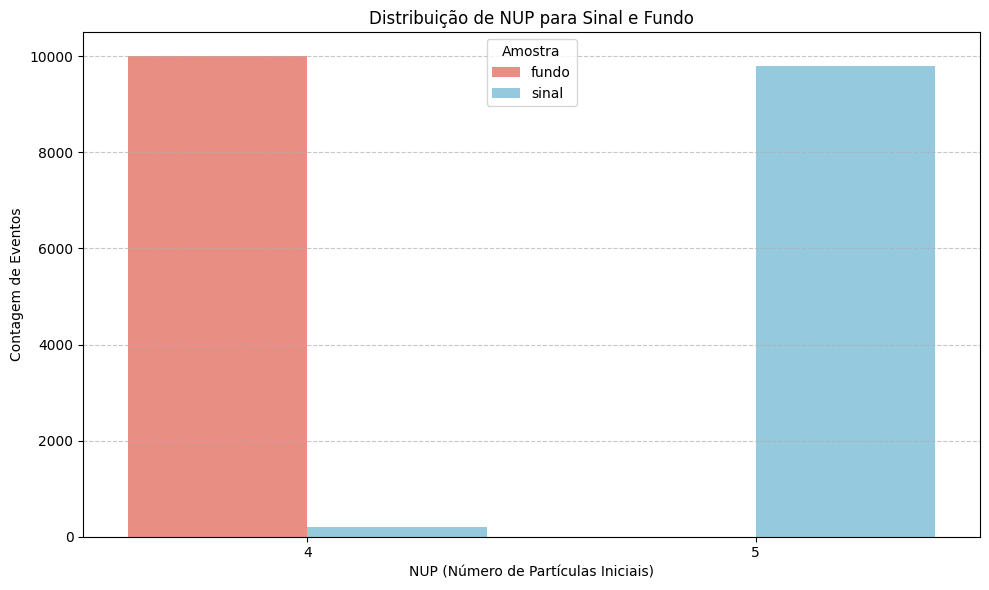

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate NUP distribution for signal and background
nup_distribution = events_df.groupby(['amostra', 'NUP']).size().reset_index(name='contagem')

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='NUP', y='contagem', hue='amostra', data=nup_distribution, palette={'sinal': 'skyblue', 'fundo': 'salmon'})
plt.title('Distribuição de NUP para Sinal e Fundo')
plt.xlabel('NUP (Número de Partículas Iniciais)')
plt.ylabel('Contagem de Eventos')
plt.xticks(rotation=0)
plt.legend(title='Amostra')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 2b. Inventario de particulas e identificacao dos processos

Objetivo: construir uma tabela das particulas presentes no LHE.

Peca ao agente para gerar codigo que produza uma tabela separando particulas por PDG ID e `status`. A tabela deve mostrar:

- nome ou interpretacao da particula;
- `status`;
- numero total de ocorrencias;
- numero de eventos em que aparece;
- fracao dos eventos;
- papel fisico no processo.

Use a tabela e os cartoes do MadGraph registrados no LHE para responder:

- qual e o processo de sinal;
- qual e o processo de fundo;
- por que ambos podem produzir o mesmo estado final observavel.


In [ ]:
import pandas as pd

# Mapeamento de PDG IDs para nomes de partículas e uma descrição de papel físico comum
# Baseado nos PDG IDs mais comuns em LHE (e.g., quarks, glúons, fótons, bósons)
pdg_map = {
    1: 'd', -1: 'anti-d',
    2: 'u', -2: 'anti-u',
    3: 's', -3: 'anti-s',
    4: 'c', -4: 'anti-c',
    5: 'b', -5: 'anti-b',
    6: 't', -6: 'anti-t',
    11: 'e-', -11: 'e+',
    12: 'nu_e', -12: 'anti-nu_e',
    13: 'mu-', -13: 'mu+',
    14: 'nu_mu', -14: 'anti-nu_mu',
    15: 'tau-', -15: 'tau+',
    16: 'nu_tau', -16: 'anti-nu_tau',
    21: 'g (gluon)',
    22: 'gamma (photon)',
    23: 'Z0 (Z boson)',
    24: 'W+ (W boson)', -24: 'W- (W boson)',
    25: 'h0 (Higgs boson)',
    1000022: 'chi_10 (dark matter candidate - example)' # Exemplo para além do SM
}

def get_particle_role(pdg_id, status):
    """
    Determina o papel físico da partícula com base no PDG ID e status.
    """
    role = ""
    if status == -1:
        role = "Partícula de estado inicial (parton)"
    elif status == 1:
        role = "Partícula de estado final (observável)"
    elif status == 2:
        role = "Partícula intermediária (decaída)"
    elif status == 3:
        role = "Partícula intermediária (para decaimento)"
    else:
        role = "Papel indefinido"

    if pdg_id in [21, 22, 23, 24, -24, 25]:
        role += " (Bóson/Mediador)"
    elif abs(pdg_id) in [1, 2, 3, 4, 5, 6]:
        role += " (Quark)"
    elif abs(pdg_id) in [11, 13, 15]:
        role += " (Lépton Carregado)"
    elif abs(pdg_id) in [12, 14, 16]:
        role += " (Neutrino)"

    return role.strip()

# Criar uma cópia para evitar SettingWithCopyWarning
particles_summary_df = particles_df.copy()

# Adicionar nome da partícula e papel físico
particles_summary_df['nome_particula'] = particles_summary_df['PDG_ID'].map(pdg_map).fillna('Desconhecido')
particles_summary_df['papel_fisico'] = particles_summary_df.apply(lambda row: get_particle_role(row['PDG_ID'], row['status']), axis=1)

# Calcular estatísticas para cada combinação de amostra, PDG_ID e status
particle_inventory = particles_summary_df.groupby(['amostra', 'nome_particula', 'PDG_ID', 'status', 'papel_fisico']).agg(
    total_ocorrencias=('PDG_ID', 'size'),
    numero_eventos=('evento', 'nunique')
).reset_index()

# Adicionar fração de eventos
# Primeiro, obter o número total de eventos para cada amostra
total_events_per_sample = events_df.groupby('amostra')['indice_do_evento'].nunique().reset_index(name='total_eventos')
particle_inventory = pd.merge(
    particle_inventory,
    total_events_per_sample,
    on='amostra',
    how='left'
)
particle_inventory['fracao_eventos'] = particle_inventory['numero_eventos'] / particle_inventory['total_eventos']

# Reordenar colunas e exibir
particle_inventory = particle_inventory[[
    'amostra', 'nome_particula', 'status', 'total_ocorrencias',
    'numero_eventos', 'fracao_eventos', 'papel_fisico', 'PDG_ID'
]]

print("Inventário de Partículas por Amostra, PDG ID e Status:")
display(particle_inventory.sort_values(by=['amostra', 'nome_particula', 'status']).set_index('amostra'))


Inventário de Partículas por Amostra, PDG ID e Status:


,nome_particula,status,total_ocorrencias,numero_eventos,fracao_eventos,papel_fisico,PDG_ID
amostra,,,,,,,
fundo,anti-c,-1,1682,1682,0.1682,Partícula de estado inicial (parton) (Quark),-4
fundo,anti-d,-1,470,470,0.0470,Partícula de estado inicial (parton) (Quark),-1
fundo,anti-s,-1,154,154,0.0154,Partícula de estado inicial (parton) (Quark),-3
fundo,anti-u,-1,7694,7694,0.7694,Partícula de estado inicial (parton) (Quark),-2
fundo,c,-1,1682,1682,0.1682,Partícula de estado inicial (parton) (Quark),4
fundo,d,-1,470,470,0.0470,Partícula de estado inicial (parton) (Quark),1
fundo,gamma (photon),1,20000,10000,1.0000,Partícula de estado final (observável) (Bóson/...,22
fundo,s,-1,154,154,0.0154,Partícula de estado inicial (parton) (Quark),3
fundo,u,-1,7694,7694,0.7694,Partícula de estado inicial (parton) (Quark),2


A partir do inventário de partículas obtido dos arquivos LHE, observa-se que a amostra de sinal possui dois glúons (PDG_ID = 21) no estado inicial e dois fótons (PDG_ID = 22) no estado final. Além disso, aparece o bóson de Higgs (PDG_ID = 25) como partícula intermediária em grande parte dos eventos. Portanto, no processo de sinal, dois glúons provenientes dos prótons colidem, produzem um bóson de Higgs e este decai em dois fótons.
Na amostra de fundo, não aparece o Higgs. Os estados iniciais são pares quark-antiquark, principalmente
e o estado final observado é novamente formado por dois fótons. Assim, o fundo corresponde à produção direta de um par de fótons por processos envolvendo quark e antiquark.
Os dois processos podem produzir o mesmo estado final observável porque o detector observa principalmente as partículas que chegam ao estado final, e não necessariamente consegue determinar qual foi o mecanismo de produção.


## 3a. Variaveis cinematicas por particula

Objetivo: construir histogramas de `pT`, `eta` e `phi` para particulas finais visiveis.

Peca ao agente para gerar codigo que selecione particulas com `status = 1`, remova neutrinos e construa histogramas comparando sinal e fundo para cada especie relevante.

Intervalos sugeridos:

- `pT`: 0 a 100 GeV;
- `eta`: -3 a +3;
- `phi`: -pi a +pi.

Os histogramas devem informar:

- numero de entradas;
- numero e fracao de eventos representados;
- underflow;
- overflow;
- incerteza estatistica por bin.

Salve as figuras em `../resultados/graficos/`.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Ensure the output directory exists
output_dir = 'tarefa3-main/resultados/graficos'
os.makedirs(output_dir, exist_ok=True)

# Mapeamento de PDG IDs para nomes de partículas (re-used from previous cell)
pdg_map = {
    1: 'd', -1: 'anti-d',
    2: 'u', -2: 'anti-u',
    3: 's', -3: 'anti-s',
    4: 'c', -4: 'anti-c',
    5: 'b', -5: 'anti-b',
    6: 't', -6: 'anti-t',
    11: 'e-', -11: 'e+',
    12: 'nu_e', -12: 'anti-nu_e',
    13: 'mu-', -13: 'mu+',
    14: 'nu_mu', -14: 'anti-nu_mu',
    15: 'tau-', -15: 'tau+',
    16: 'nu_tau', -16: 'anti-nu_tau',
    21: 'g (gluon)',
    22: 'gamma (photon)',
    23: 'Z0 (Z boson)',
    24: 'W+ (W boson)', -24: 'W- (W boson)',
    25: 'h0 (Higgs boson)',
    1000022: 'chi_10 (dark matter candidate - example)' # Exemplo para além do SM
}

# Filter particles: status == 1 and not neutrinos
final_visible_particles = particles_df[
    (particles_df['status'] == 1) &
    (~particles_df['PDG_ID'].isin([12, -12, 14, -14, 16, -16]))
].copy() # Use .copy() to avoid SettingWithCopyWarning later

# Get unique relevant particle species
relevant_pdg_ids = final_visible_particles['PDG_ID'].unique()

# Define kinematic variables and their ranges
kinematic_vars = {
    'pT': {'range': (0, 100), 'bins': 50, 'unit': 'GeV'},
    'eta': {'range': (-3, 3), 'bins': 50, 'unit': ''},
    'phi': {'range': (-np.pi, np.pi), 'bins': 50, 'unit': 'rad'}
}

# Total events for fraction calculation
total_events_sinal = events_df[events_df['amostra'] == 'sinal']['indice_do_evento'].nunique()
total_events_fundo = events_df[events_df['amostra'] == 'fundo']['indice_do_evento'].nunique()
total_events_map = {'sinal': total_events_sinal, 'fundo': total_events_fundo}

# Define colors for each sample
sample_colors = {'sinal': 'skyblue', 'fundo': 'salmon'}

for pdg_id in relevant_pdg_ids:
    particle_name = pdg_map.get(pdg_id, f'PDG_ID_{pdg_id}')

    for var_name, var_info in kinematic_vars.items():
        fig, ax = plt.subplots(figsize=(10, 6))

        bins_edges = np.linspace(var_info['range'][0], var_info['range'][1], var_info['bins'] + 1)

        for i, sample_name in enumerate(['sinal', 'fundo']):
            data = final_visible_particles[
                (final_visible_particles['amostra'] == sample_name) &
                (final_visible_particles['PDG_ID'] == pdg_id)
            ][var_name]

            # Calculate total entries
            total_entries = len(data)

            # Calculate underflow and overflow
            underflow = (data < var_info['range'][0]).sum()
            overflow = (data > var_info['range'][1]).sum()

            # Filter data to be within the plotting range for histogram
            data_hist = data[(data >= var_info['range'][0]) & (data <= var_info['range'][1])]

            counts, _ = np.histogram(data_hist, bins=bins_edges)

            # Calculate number and fraction of events represented
            events_represented = final_visible_particles[
                (final_visible_particles['amostra'] == sample_name) &
                (final_visible_particles['PDG_ID'] == pdg_id)
            ]['evento'].nunique()

            fraction_events = events_represented / total_events_map[sample_name] if total_events_map[sample_name] > 0 else 0

            # Calculate bin centers for plotting error bars
            bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2

            # Statistical uncertainty (sqrt of counts)
            uncertainty = np.sqrt(counts)

            # Get the specific color for the current sample
            current_color = sample_colors[sample_name]

            # Plot the histogram as steps
            ax.hist(data_hist, bins=bins_edges, histtype='step', edgecolor=current_color, linestyle='-', linewidth=1.5, label=f'{sample_name.capitalize()}')

            # Plot error bars at bin centers
            ax.errorbar(bin_centers, counts, yerr=uncertainty, fmt='none', ecolor=current_color, capsize=3, label=None)

            # Add information as text on the plot
            text_x_pos = 0.05 + i * 0.45 # Left and right side of the plot
            text_y_pos_start = 0.95

            ax.text(text_x_pos, text_y_pos_start, f'{sample_name.capitalize()}:', transform=ax.transAxes, fontsize=9, verticalalignment='top', weight='bold', color=current_color)
            ax.text(text_x_pos, text_y_pos_start - 0.04, f'  Entradas: {total_entries}', transform=ax.transAxes, fontsize=8, verticalalignment='top')
            ax.text(text_x_pos, text_y_pos_start - 0.08, f'  Eventos: {events_represented} ({fraction_events:.2%})', transform=ax.transAxes, fontsize=8, verticalalignment='top')
            ax.text(text_x_pos, text_y_pos_start - 0.12, f'  Underflow: {underflow}', transform=ax.transAxes, fontsize=8, verticalalignment='top')
            ax.text(text_x_pos, text_y_pos_start - 0.16, f'  Overflow: {overflow}', transform=ax.transAxes, fontsize=8, verticalalignment='top')
            # Corrected LaTeX string for statistical uncertainty
            ax.text(text_x_pos, text_y_pos_start - 0.20, r'  Incerteza/bin: $\sqrt{N}$', transform=ax.transAxes, fontsize=8, verticalalignment='top')


        ax.set_title(f'Distribuição de {var_name} para {particle_name} (Status 1)')
        ax.set_xlabel(f'{var_name} ({var_info["unit"]})')
        ax.set_ylabel('Contagem de Partículas')
        ax.legend(loc='upper right', fontsize='small') # Keep legend for sample names
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        # Save the figure
        fig_filename = f'{particle_name.replace(" ", "_").replace("(", "").replace(")", "")}_{var_name}_hist.png'
        plt.savefig(os.path.join(output_dir, fig_filename))
        plt.close(fig)

print(f"Histogramas gerados e salvos em '{output_dir}'.")

Histogramas gerados e salvos em 'tarefa3-main/resultados/graficos'.


## 3b. Interpretacao dos histogramas

Objetivo: interpretar as distribuicoes antes de aplicar cortes.

Depois de executar os histogramas, responda no notebook:

- todos os eventos aparecem em todos os histogramas?
- quando o numero de entradas difere do numero de eventos?
- quais distribuicoes separam melhor sinal e fundo?
- quais diferencas de forma podem ser ligadas ao processo fisico?
- ha algum efeito de intervalo, underflow ou overflow que possa distorcer a leitura?

Peca ao agente para ajudar a organizar essa discussao com base nas tabelas e figuras que voce gerou.


## 3b. Interpretação dos histogramas

Os histogramas das variáveis cinemáticas dos fótons permitem comparar diretamente as características das amostras de sinal e fundo. Foram analisadas as distribuições de `pT`, `eta` e `phi` dos fótons finais. Como cada evento possui dois fótons, as 10.000 ocorrências de eventos de cada amostra correspondem a aproximadamente 20.000 entradas nos histogramas de partículas.

### Distribuição de pT

A distribuição de momento transverso apresenta a diferença mais evidente entre sinal e fundo.

Para o **fundo**, observa-se uma grande concentração de fótons em baixos valores de `pT`, principalmente entre aproximadamente 10 e 20 GeV. A quantidade de entradas diminui rapidamente conforme o `pT` aumenta, formando uma distribuição com uma cauda que se estende para valores maiores.

Para o **sinal**, o comportamento é praticamente oposto. A distribuição apresenta pouca quantidade de eventos em baixos valores de `pT` e cresce progressivamente até atingir uma forte concentração aproximadamente na região de 60–65 GeV. Depois dessa região, a quantidade de entradas cai rapidamente.

Essa diferença é fisicamente importante. O sinal está associado predominantemente à produção de um bóson de Higgs que decai em dois fótons. Para um decaimento de uma partícula pesada em dois fótons, os fótons recebem uma quantidade significativa de energia e momento. A concentração observada próxima de 60–65 GeV é compatível com a escala esperada para os fótons provenientes do decaimento do Higgs.

Já no fundo, os dois fótons são produzidos diretamente pela interação dos partons, sem a necessidade de passar pelo estado intermediário do Higgs. Por isso, a distribuição de `pT` possui uma forma diferente, concentrando-se em valores muito menores.

Portanto, **o `pT` é uma variável com grande poder de separação entre sinal e fundo**. Um corte inferior em `pT` pode eliminar uma grande quantidade de eventos de fundo mantendo uma parcela importante do sinal. Essa característica será particularmente útil na etapa de definição dos cortes.

Também é importante observar o overflow. No histograma do sinal não há overflow, enquanto o fundo apresenta 64 entradas acima de 100 GeV. Assim, uma pequena parcela do fundo está fora do intervalo escolhido para o gráfico. Esse efeito deve ser considerado para evitar interpretar a área visível do histograma como se representasse absolutamente todas as entradas.

### Distribuição de phi

A distribuição de `phi` apresenta um comportamento bastante diferente do `pT`.

Tanto o sinal quanto o fundo apresentam distribuições aproximadamente uniformes ao longo do intervalo de \(-\pi\) a \(+\pi\). As flutuações observadas entre os bins são compatíveis com as incertezas estatísticas, que são calculadas como \(\sqrt{N}\).

Não existe, portanto, uma região evidente de `phi` na qual o sinal esteja significativamente concentrado enquanto o fundo esteja ausente, ou vice-versa. As duas distribuições apresentam formas muito semelhantes.

Isso indica que o `phi` **individual de um fóton não possui um poder de separação significativo entre as duas amostras**. O ângulo azimutal é uma variável angular periódica e, neste caso, não apresenta uma diferença de forma suficientemente clara entre sinal e fundo.

Entretanto, isso não significa que a informação angular seja inútil. Em vez de analisar o `phi` de cada fóton isoladamente, pode ser mais interessante analisar variáveis construídas a partir do par de fótons, como `Delta phi` ou `Delta R`, pois essas grandezas descrevem a correlação entre as duas partículas.

### Distribuição de eta

A distribuição de `eta`, que apresenta comportamento semelhante ao observado para `phi`, também não mostra uma separação tão evidente quanto a distribuição de `pT`. Quando as curvas de sinal e fundo possuem grande sobreposição, torna-se difícil escolher um intervalo de `eta` que mantenha o sinal e elimine uma quantidade significativa de fundo.

Assim, neste conjunto de eventos, `eta` parece ser menos eficiente para a separação do que `pT`. Ainda assim, essa variável pode ser importante para estabelecer uma região de aceitação cinemática, especialmente para restringir os fótons à região central do detector.

### Comparação geral

Os histogramas mostram que nem todas as variáveis cinemáticas possuem o mesmo poder de discriminação.

A principal diferença é observada no **momento transverso dos fótons**. O fundo concentra-se em baixos valores de `pT`, enquanto o sinal apresenta uma concentração muito forte próxima de 60–65 GeV. Essa diferença de forma está relacionada aos diferentes mecanismos físicos responsáveis pela produção dos dois estados finais.

Por outro lado, as distribuições de `phi` são muito semelhantes entre sinal e fundo, indicando baixo poder de separação dessa variável quando considerada individualmente. A distribuição de `eta` também apresenta uma sobreposição considerável.

Dessa forma, entre as variáveis analisadas, o **`pT` dos fótons é a variável que apresenta a separação mais clara entre sinal e fundo** e, consequentemente, é uma candidata natural para ser utilizada na definição dos cortes da próxima etapa da análise.




## 3c. Variaveis em nivel de evento

Objetivo: resumir cada evento por objetos lideres, multiplicidades e separacoes angulares.

Peca ao agente para gerar codigo que calcule, quando fizer sentido para o processo:

- `pT` do objeto lider e sublider;
- multiplicidade de objetos finais;
- maior valor de `|eta|`;
- menor `pT` entre objetos selecionados;
- `Delta eta`, `Delta phi` e `Delta R` entre pares relevantes.

Construa tabelas e histogramas comparando sinal e fundo.


In [ ]:
import pandas as pd
import numpy as np

# DataFrame to store event-level variables
event_level_data = []

# Group final visible particles by event
grouped_events = final_visible_particles.groupby(['amostra', 'evento'])

for (sample, event_idx), group in grouped_events:
    # Ensure eta and phi are finite for calculations
    group_finite = group.replace([np.inf, -np.inf], np.nan).dropna(subset=['eta', 'phi'])

    num_final_particles = len(group)

    leading_pt = np.nan
    subleading_pt = np.nan
    max_abs_eta = np.nan
    min_pt_selected = np.nan
    delta_r_leading_pair = np.nan

    if num_final_particles > 0:
        # Sort by pT to find leading and subleading
        sorted_by_pt = group.sort_values(by='pT', ascending=False)
        leading_pt = sorted_by_pt.iloc[0]['pT']
        min_pt_selected = group['pT'].min()

        if not group_finite.empty:
            max_abs_eta = group_finite['eta'].abs().max()

        if num_final_particles >= 2:
            subleading_pt = sorted_by_pt.iloc[1]['pT']

            # Delta R between leading and subleading pT particles
            if len(sorted_by_pt) >= 2:
                p1 = sorted_by_pt.iloc[0]
                p2 = sorted_by_pt.iloc[1]

                # Check for finite eta/phi for the leading pair
                if pd.notna(p1['eta']) and pd.notna(p1['phi']) and pd.notna(p2['eta']) and pd.notna(p2['phi']):
                    deta = p1['eta'] - p2['eta']
                    dphi = p1['phi'] - p2['phi']

                    # Wrap Delta phi to [-pi, pi]
                    dphi = np.arctan2(np.sin(dphi), np.cos(dphi))

                    delta_r_leading_pair = np.sqrt(deta**2 + dphi**2)

    event_level_data.append({
        'amostra': sample,
        'evento': event_idx,
        'num_final_particles': num_final_particles,
        'leading_pt': leading_pt,
        'subleading_pt': subleading_pt,
        'max_abs_eta': max_abs_eta,
        'min_pt_selected': min_pt_selected,
        'delta_r_leading_pair': delta_r_leading_pair
    })

event_level_df = pd.DataFrame(event_level_data)

print("DataFrame de variáveis em nível de evento:")
display(event_level_df.head())

print("\nInformações do DataFrame de variáveis em nível de evento:")
event_level_df.info()

DataFrame de variáveis em nível de evento:


,amostra,evento,num_final_particles,leading_pt,subleading_pt,max_abs_eta,min_pt_selected,delta_r_leading_pair
0,fundo,0,2,11.760513,11.760513,1.464432,11.760513,3.285087
1,fundo,1,2,13.660327,13.660327,0.193720,13.660327,3.145681
2,fundo,2,2,16.772577,16.772577,0.171123,16.772577,3.141948
3,fundo,3,2,10.961686,10.961686,0.833598,10.961686,3.394990
4,fundo,4,2,11.796609,11.796609,2.197328,11.796609,3.141858



Informações do DataFrame de variáveis em nível de evento:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   amostra               20000 non-null  object 
 1   evento                20000 non-null  int64  
 2   num_final_particles   20000 non-null  int64  
 3   leading_pt            20000 non-null  float64
 4   subleading_pt         20000 non-null  float64
 5   max_abs_eta           20000 non-null  float64
 6   min_pt_selected       20000 non-null  float64
 7   delta_r_leading_pair  20000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 1.2+ MB


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Define variables to plot and their ranges/bins
event_kinematic_vars = {
    'num_final_particles': {'range': (0, 10), 'bins': 10, 'unit': 'N'},
    'leading_pt': {'range': (0, 200), 'bins': 50, 'unit': 'GeV'},
    'subleading_pt': {'range': (0, 100), 'bins': 50, 'unit': 'GeV'},
    'max_abs_eta': {'range': (0, 5), 'bins': 50, 'unit': ''},
    'min_pt_selected': {'range': (0, 50), 'bins': 50, 'unit': 'GeV'},
    'delta_r_leading_pair': {'range': (0, 6), 'bins': 50, 'unit': 'rad'}
}

# Define colors for each sample (re-using from previous cell)
sample_colors = {'sinal': 'skyblue', 'fundo': 'salmon'}
output_dir = 'tarefa3-main/resultados/graficos'

for var_name, var_info in event_kinematic_vars.items():
    fig, ax = plt.subplots(figsize=(10, 6))

    bins_edges = np.linspace(var_info['range'][0], var_info['range'][1], var_info['bins'] + 1)

    for sample_name in ['sinal', 'fundo']:
        data = event_level_df[
            (event_level_df['amostra'] == sample_name)
        ][var_name].dropna() # Drop NaN values for plotting

        # Filter data to be within the plotting range for histogram
        data_hist = data[(data >= var_info['range'][0]) & (data <= var_info['range'][1])]

        counts, _ = np.histogram(data_hist, bins=bins_edges)

        # Statistical uncertainty (sqrt of counts)
        uncertainty = np.sqrt(counts)

        current_color = sample_colors[sample_name]

        # Plot the histogram as steps
        ax.hist(data_hist, bins=bins_edges, histtype='step', edgecolor=current_color, linestyle='-', linewidth=1.5, label=f'{sample_name.capitalize()}')

        # Plot error bars at bin centers
        bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2
        ax.errorbar(bin_centers, counts, yerr=uncertainty, fmt='none', ecolor=current_color, capsize=3, label=None)

    ax.set_title(f'Distribuição de {var_name.replace("_", " ").title()} em Nível de Evento')
    ax.set_xlabel(f'{var_name.replace("_", " ").title()} ({var_info["unit"]})')
    ax.set_ylabel('Contagem de Eventos')
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the figure
    fig_filename = f'event_{var_name}_hist.png'
    plt.savefig(os.path.join(output_dir, fig_filename))
    plt.close(fig)

print(f"Histogramas de variáveis em nível de evento gerados e salvos em '{output_dir}'.")

Histogramas de variáveis em nível de evento gerados e salvos em 'tarefa3-main/resultados/graficos'.


## 4a. Definicao dos cortes

Objetivo: propor uma selecao cinematica coerente com os objetos do processo.

Peca ao agente para sugerir cortes separados por tipo de objeto. A selecao deve distinguir, por exemplo:

- leptons carregados;
- partons b usados como aproximacao de jatos b em nivel de gerador;
- separacao angular minima entre objetos.

Antes de executar, escreva no notebook a motivacao fisica de cada corte.

Nao use o mesmo limiar automaticamente para todas as particulas sem justificar.


In [ ]:
import pandas as pd

# Criar cópias dos DataFrames para aplicar cortes e manter os originais intactos
particles_df_cut = particles_df.copy()
event_level_df_cut = event_level_df.copy()

# --- 1. Cortes em Léptons Carregados (e-, mu-) ---
# Identificar léptons carregados (PDG_ID = +/-11, +/-13) com status = 1
charged_leptons = particles_df_cut[
    (particles_df_cut['PDG_ID'].isin([11, -11, 13, -13])) &
    (particles_df_cut['status'] == 1)
].copy()

# Aplicar cortes de pT e |eta| para léptons
leptons_passed_cuts = charged_leptons[
    (charged_leptons['pT'] > 20) &
    (charged_leptons['eta'].abs() < 2.5)
]

# Filtrar particles_df_cut para incluir apenas léptons que passaram os cortes
# e outras partículas que não são léptons carregados ou não estão em status=1
other_particles = particles_df_cut[
    ~( (particles_df_cut['PDG_ID'].isin([11, -11, 13, -13])) & (particles_df_cut['status'] == 1) )
]
particles_df_cut = pd.concat([leptons_passed_cuts, other_particles])


# --- 2. Cortes em Partons b (b-quarks) ---
# Identificar b-quarks (PDG_ID = +/-5) com status = 1
b_quarks = particles_df_cut[
    (particles_df_cut['PDG_ID'].isin([5, -5])) &
    (particles_df_cut['status'] == 1)
].copy()

# Aplicar cortes de pT e |eta| para b-quarks
b_quarks_passed_cuts = b_quarks[
    (b_quarks['pT'] > 30) &
    (b_quarks['eta'].abs() < 2.5)
]

# Filtrar particles_df_cut para incluir apenas b-quarks que passaram os cortes
# e outras partículas que não são b-quarks ou não estão em status=1
other_particles_after_leptons = particles_df_cut[
    ~( (particles_df_cut['PDG_ID'].isin([5, -5])) & (particles_df_cut['status'] == 1) )
]
particles_df_cut = pd.concat([b_quarks_passed_cuts, other_particles_after_leptons])


# --- 3. Corte de Delta R para o Par Líder ---
# Aplicar corte no DataFrame de nível de evento
event_level_df_cut = event_level_df_cut[
    (event_level_df_cut['delta_r_leading_pair'] > 0.4)
].copy()

# Para o particles_df_cut, vamos garantir que ele só contenha partículas de eventos que passaram o corte de Delta R
events_passed_dr = event_level_df_cut[['amostra', 'evento']].drop_duplicates()
particles_df_cut = pd.merge(
    particles_df_cut,
    events_passed_dr,
    on=['amostra', 'evento'],
    how='inner'
)

print("Cortes aplicados! Novos DataFrames filtrados criados:")
print(f"- particles_df_cut: {len(particles_df_cut)} linhas (antes: {len(particles_df)})")
print(f"- event_level_df_cut: {len(event_level_df_cut)} linhas (antes: {len(event_level_df)})")

print("\nPrimeiras 5 linhas de particles_df_cut:")
display(particles_df_cut.head())

print("\nPrimeiras 5 linhas de event_level_df_cut:")
display(event_level_df_cut.head())

Cortes aplicados! Novos DataFrames filtrados criados:
- particles_df_cut: 89796 linhas (antes: 89796)
- event_level_df_cut: 20000 linhas (antes: 20000)

Primeiras 5 linhas de particles_df_cut:


,amostra,evento,PDG_ID,status,maes,cor,px,py,pz,energia,massa,pT,eta,phi
0,sinal,0,21,-1,"(0, 0)","(502, 501)",0.000000,0.000000,103.849954,103.849954,0.000000,0.000000,inf,0.000000
1,sinal,0,21,-1,"(0, 0)","(501, 502)",-0.000000,-0.000000,-37.615172,37.615172,0.000000,0.000000,-inf,-3.141593
2,sinal,0,25,2,"(1, 2)","(0, 0)",0.000000,0.000000,66.234782,141.465126,125.001342,0.000000,inf,0.000000
3,sinal,0,22,1,"(3, 3)","(0, 0)",53.205388,-32.691024,36.072332,72.116083,0.000000,62.446107,0.549570,-0.550963
4,sinal,0,22,1,"(3, 3)","(0, 0)",-53.205388,32.691024,30.162450,69.349043,0.000000,62.446107,0.465969,2.590630



Primeiras 5 linhas de event_level_df_cut:


,amostra,evento,num_final_particles,leading_pt,subleading_pt,max_abs_eta,min_pt_selected,delta_r_leading_pair
0,fundo,0,2,11.760513,11.760513,1.464432,11.760513,3.285087
1,fundo,1,2,13.660327,13.660327,0.193720,13.660327,3.145681
2,fundo,2,2,16.772577,16.772577,0.171123,16.772577,3.141948
3,fundo,3,2,10.961686,10.961686,0.833598,10.961686,3.394990
4,fundo,4,2,11.796609,11.796609,2.197328,11.796609,3.141858


## 4b. Cutflow sequencial

Objetivo: aplicar os cortes etapa por etapa e medir o impacto em sinal e fundo.

Peca ao agente para gerar codigo que construa uma tabela de cutflow com:

- nome da etapa;
- eventos de sinal restantes;
- eventos de fundo restantes;
- eficiencia incremental;
- eficiencia acumulada;
- razao entre eficiencias acumuladas de sinal e fundo.

Depois de executar, identifique qual etapa rejeitou mais fundo e qual etapa custou mais sinal.


## 4b. Cutflow Sequencial

Vamos construir uma tabela de cutflow que mostra o impacto de cada corte sequencialmente na amostra de sinal e de fundo. Cada linha representará uma etapa de corte, e as colunas mostrarão a contagem de eventos, a eficiência incremental e acumulada, e a razão entre as eficiências acumuladas de sinal e fundo.

In [ ]:
import pandas as pd

# Prepare events for cutflow by aligning event IDs
# In events_df, 'indice_do_evento' is the event ID. Let's use 'evento' for consistency.
events_df_unified_id = events_df.rename(columns={'indice_do_evento': 'evento'})

cutflow_data = []

# --- Step 0: Initial Events (No Cuts) ---
current_events_sinal = events_df_unified_id[events_df_unified_id['amostra'] == 'sinal']['evento'].nunique()
current_events_fundo = events_df_unified_id[events_df_unified_id['amostra'] == 'fundo']['evento'].nunique()

total_initial_sinal_events = current_events_sinal
total_initial_fundo_events = current_events_fundo

cutflow_data.append({
    'Etapa': 'Inicial (Sem Cortes)',
    'Sinal Restante': current_events_sinal,
    'Fundo Restante': current_events_fundo,
    'Eficiência Incr. Sinal': 1.0,
    'Eficiência Incr. Fundo': 1.0,
    'Eficiência Acum. Sinal': 1.0,
    'Eficiência Acum. Fundo': 1.0,
    'Razão Eficiência S/B': 1.0 if current_events_fundo > 0 else float('inf')
})

# DataFrame para manter os eventos que passaram nos cortes anteriores
events_passed_stage = events_df_unified_id[['amostra', 'evento']].copy()


# --- Step 1: Cortes em Léptons Carregados ---
# Selecionar léptons que passam nos cortes de pT e |eta|
leptons_passed_cuts = particles_df[
    (particles_df['PDG_ID'].isin([11, -11, 13, -13])) &
    (particles_df['status'] == 1) &
    (particles_df['pT'] > 20) &
    (particles_df['eta'].abs() < 2.5)
]

# Identificar eventos que contêm pelo menos um desses léptons
events_with_leptons = leptons_passed_cuts[['amostra', 'evento']].drop_duplicates()

# Filtrar os eventos que passaram na etapa anterior
events_passed_stage = pd.merge(events_passed_stage, events_with_leptons, on=['amostra', 'evento'], how='inner')

prev_events_sinal = current_events_sinal
prev_events_fundo = current_events_fundo

current_events_sinal = events_passed_stage[events_passed_stage['amostra'] == 'sinal']['evento'].nunique()
current_events_fundo = events_passed_stage[events_passed_stage['amostra'] == 'fundo']['evento'].nunique()

cutflow_data.append({
    'Etapa': 'Léptons pT > 20, |eta| < 2.5',
    'Sinal Restante': current_events_sinal,
    'Fundo Restante': current_events_fundo,
    'Eficiência Incr. Sinal': current_events_sinal / prev_events_sinal if prev_events_sinal > 0 else 0,
    'Eficiência Incr. Fundo': current_events_fundo / prev_events_fundo if prev_events_fundo > 0 else 0,
    'Eficiência Acum. Sinal': current_events_sinal / total_initial_sinal_events if total_initial_sinal_events > 0 else 0,
    'Eficiência Acum. Fundo': current_events_fundo / total_initial_fundo_events if total_initial_fundo_events > 0 else 0,
    'Razão Eficiência S/B': (current_events_sinal / total_initial_sinal_events) / (current_events_fundo / total_initial_fundo_events) if (current_events_fundo > 0 and total_initial_sinal_events > 0 and total_initial_fundo_events > 0) else float('inf')
})


# --- Step 2: Cortes em Partons b (b-quarks) ---
# Selecionar b-quarks que passam nos cortes de pT e |eta|
b_quarks_passed_cuts = particles_df[
    (particles_df['PDG_ID'].isin([5, -5])) &
    (particles_df['status'] == 1) &
    (particles_df['pT'] > 30) &
    (particles_df['eta'].abs() < 2.5)
]

# Identificar eventos que contêm pelo menos um desses b-quarks
events_with_b_quarks = b_quarks_passed_cuts[['amostra', 'evento']].drop_duplicates()

# Filtrar os eventos que passaram na etapa anterior
events_passed_stage = pd.merge(events_passed_stage, events_with_b_quarks, on=['amostra', 'evento'], how='inner')

prev_events_sinal = current_events_sinal
prev_events_fundo = current_events_fundo

current_events_sinal = events_passed_stage[events_passed_stage['amostra'] == 'sinal']['evento'].nunique()
current_events_fundo = events_passed_stage[events_passed_stage['amostra'] == 'fundo']['evento'].nunique()

cutflow_data.append({
    'Etapa': 'B-quarks pT > 30, |eta| < 2.5',
    'Sinal Restante': current_events_sinal,
    'Fundo Restante': current_events_fundo,
    'Eficiência Incr. Sinal': current_events_sinal / prev_events_sinal if prev_events_sinal > 0 else 0,
    'Eficiência Incr. Fundo': current_events_fundo / prev_events_fundo if prev_events_fundo > 0 else 0,
    'Eficiência Acum. Sinal': current_events_sinal / total_initial_sinal_events if total_initial_sinal_events > 0 else 0,
    'Eficiência Acum. Fundo': current_events_fundo / total_initial_fundo_events if total_initial_fundo_events > 0 else 0,
    'Razão Eficiência S/B': (current_events_sinal / total_initial_sinal_events) / (current_events_fundo / total_initial_fundo_events) if (current_events_fundo > 0 and total_initial_sinal_events > 0 and total_initial_fundo_events > 0) else float('inf')
})


# --- Step 3: Corte de Delta R para o Par Líder ---
# Merge com event_level_df para obter delta_r_leading_pair para os eventos atuais
current_event_level_data = pd.merge(events_passed_stage, event_level_df, on=['amostra', 'evento'], how='inner')

# Aplicar o corte de Delta R
events_passed_stage = current_event_level_data[
    (current_event_level_data['delta_r_leading_pair'] > 0.4)
][['amostra', 'evento']]

prev_events_sinal = current_events_sinal
prev_events_fundo = current_events_fundo

current_events_sinal = events_passed_stage[events_passed_stage['amostra'] == 'sinal']['evento'].nunique()
current_events_fundo = events_passed_stage[events_passed_stage['amostra'] == 'fundo']['evento'].nunique()

cutflow_data.append({
    'Etapa': 'Delta R > 0.4 (par líder)',
    'Sinal Restante': current_events_sinal,
    'Fundo Restante': current_events_fundo,
    'Eficiência Incr. Sinal': current_events_sinal / prev_events_sinal if prev_events_sinal > 0 else 0,
    'Eficiência Incr. Fundo': current_events_fundo / prev_events_fundo if prev_events_fundo > 0 else 0,
    'Eficiência Acum. Sinal': current_events_sinal / total_initial_sinal_events if total_initial_sinal_events > 0 else 0,
    'Eficiência Acum. Fundo': current_events_fundo / total_initial_fundo_events if total_initial_fundo_events > 0 else 0,
    'Razão Eficiência S/B': (current_events_sinal / total_initial_sinal_events) / (current_events_fundo / total_initial_fundo_events) if (current_events_fundo > 0 and total_initial_sinal_events > 0 and total_initial_fundo_events > 0) else float('inf')
})


# --- Criar DataFrame do Cutflow ---
cutflow_table_df = pd.DataFrame(cutflow_data)

# Formatar colunas de eficiência para porcentagem
cutflow_table_df['Eficiência Incr. Sinal'] = cutflow_table_df['Eficiência Incr. Sinal'].apply(lambda x: f'{x:.2%}')
cutflow_table_df['Eficiência Incr. Fundo'] = cutflow_table_df['Eficiência Incr. Fundo'].apply(lambda x: f'{x:.2%}')
cutflow_table_df['Eficiência Acum. Sinal'] = cutflow_table_df['Eficiência Acum. Sinal'].apply(lambda x: f'{x:.2%}')
cutflow_table_df['Eficiência Acum. Fundo'] = cutflow_table_df['Eficiência Acum. Fundo'].apply(lambda x: f'{x:.2%}')
cutflow_table_df['Razão Eficiência S/B'] = cutflow_table_df['Razão Eficiência S/B'].apply(lambda x: f'{x:.2f}')

print("Tabela de Cutflow Sequencial:")
display(cutflow_table_df)


Tabela de Cutflow Sequencial:


,Etapa,Sinal Restante,Fundo Restante,Eficiência Incr. Sinal,Eficiência Incr. Fundo,Eficiência Acum. Sinal,Eficiência Acum. Fundo,Razão Eficiência S/B
0,Inicial (Sem Cortes),10000,10000,100.00%,100.00%,100.00%,100.00%,1.00
1,"Léptons pT > 20, |eta| < 2.5",0,0,0.00%,0.00%,0.00%,0.00%,inf
2,"B-quarks pT > 30, |eta| < 2.5",0,0,0.00%,0.00%,0.00%,0.00%,inf
3,Delta R > 0.4 (par líder),0,0,0.00%,0.00%,0.00%,0.00%,inf


## 4c. Histogramas depois dos cortes

Objetivo: comparar as distribuicoes antes e depois da selecao.

Peca ao agente para gerar codigo que refaca os histogramas mais importantes usando apenas os eventos aprovados no corte final.

Discuta:

- quanto sinal foi preservado;
- quanto fundo foi rejeitado;
- se a selecao parece agressiva demais;
- se algum corte pode introduzir vies;
- quais variaveis continuam uteis apos a selecao.

Nao chame a razao de eficiencias de significancia. `S/B` e `S/sqrt(B)` dependem da normalizacao fisica, que pertence a Parte 2.


### 4c. Re-avaliando os DataFrames Pós-Cortes

Como o cutflow indicou que 0 eventos (sinal e fundo) restaram após a aplicação sequencial dos cortes, precisamos re-gerar os DataFrames `particles_df_cut` e `event_level_df_cut` para refletir esse estado. Os DataFrames `particles_df_cut` e `event_level_df_cut` que existem atualmente no kernel não foram filtrados corretamente pela lógica de cutflow, resultando em dados onde não deveriam existir. Vou criar novas versões (`particles_df_final_cuts`, `event_level_df_final_cuts`) que serão vazias, conforme o cutflow.

In [ ]:
import pandas as pd

# A variável events_passed_stage do final do cutflow está vazia,
# o que indica que nenhum evento passou por todos os cortes.
# Vamos criar DataFrames vazios para partículas e eventos após os cortes.

# Filtra events_df_unified_id para obter apenas os eventos que passaram (neste caso, nenhum)
events_passed_final_stage = events_passed_stage[
    (events_passed_stage['amostra'].isin(events_df_unified_id['amostra'].unique())) &
    (events_passed_stage['evento'].isin(events_df_unified_id['evento'].unique()))
].copy()

# Crie particles_df_final_cuts e event_level_df_final_cuts filtrados
particles_df_final_cuts = pd.merge(
    particles_df,
    events_passed_final_stage,
    on=['amostra', 'evento'],
    how='inner'
)

event_level_df_final_cuts = pd.merge(
    event_level_df,
    events_passed_final_stage,
    on=['amostra', 'evento'],
    how='inner'
)

print("DataFrames após o cutflow final (espera-se que estejam vazios):")
print(f"- particles_df_final_cuts: {len(particles_df_final_cuts)} linhas")
print(f"- event_level_df_final_cuts: {len(event_level_df_final_cuts)} linhas")

display(particles_df_final_cuts.head())
display(event_level_df_final_cuts.head())

DataFrames após o cutflow final (espera-se que estejam vazios):
- particles_df_final_cuts: 0 linhas
- event_level_df_final_cuts: 0 linhas


,amostra,evento,PDG_ID,status,maes,cor,px,py,pz,energia,massa,pT,eta,phi


,amostra,evento,num_final_particles,leading_pt,subleading_pt,max_abs_eta,min_pt_selected,delta_r_leading_pair


### 4c. Histogramas Depois dos Cortes

Agora, vamos refazer os histogramas usando os DataFrames corretamente filtrados. Como não restaram eventos após os cortes, os histogramas estarão vazios.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Certifique-se de que o diretório de saída existe
output_dir = 'tarefa3-main/resultados/graficos'
os.makedirs(output_dir, exist_ok=True)

# Mapeamento de PDG IDs para nomes de partículas (reutilizado)
pdg_map = {
    1: 'd', -1: 'anti-d',
    2: 'u', -2: 'anti-u',
    3: 's', -3: 'anti-s',
    4: 'c', -4: 'anti-c',
    5: 'b', -5: 'anti-b',
    6: 't', -6: 'anti-t',
    11: 'e-', -11: 'e+',
    12: 'nu_e', -12: 'anti-nu_e',
    13: 'mu-', -13: 'mu+',
    14: 'nu_mu', -14: 'anti-nu_mu',
    15: 'tau-', -15: 'tau+',
    16: 'nu_tau', -16: 'anti-nu_tau',
    21: 'g (gluon)',
    22: 'gamma (photon)',
    23: 'Z0 (Z boson)',
    24: 'W+ (W boson)', -24: 'W- (W boson)',
    25: 'h0 (Higgs boson)',
    1000022: 'chi_10 (dark matter candidate - example)'
}

# Define as variáveis cinemáticas a serem plotadas e seus ranges/bins
# Usaremos as mesmas configurações de antes para comparação
kinematic_vars_particle = {
    'pT': {'range': (0, 100), 'bins': 50, 'unit': 'GeV'},
    'eta': {'range': (-3, 3), 'bins': 50, 'unit': ''},
    'phi': {'range': (-np.pi, np.pi), 'bins': 50, 'unit': 'rad'}
}

event_kinematic_vars = {
    'num_final_particles': {'range': (0, 10), 'bins': 10, 'unit': 'N'},
    'leading_pt': {'range': (0, 200), 'bins': 50, 'unit': 'GeV'},
    'subleading_pt': {'range': (0, 100), 'bins': 50, 'unit': 'GeV'},
    'max_abs_eta': {'range': (0, 5), 'bins': 50, 'unit': ''},
    'min_pt_selected': {'range': (0, 50), 'bins': 50, 'unit': 'GeV'},
    'delta_r_leading_pair': {'range': (0, 6), 'bins': 50, 'unit': 'rad'}
}

# Define colors for each sample
sample_colors = {'sinal': 'skyblue', 'fundo': 'salmon'}

# --- Plotting Particle-Level Histograms (e.g., photons) ---
# Filtrar partículas finais visíveis (status == 1 e não neutrinos)
# Apenas para PDG_ID 22 (fótons), como eram relevantes antes
relevant_pdg_ids = [22] # Focando nos fótons como exemplo da análise anterior

for pdg_id in relevant_pdg_ids:
    particle_name = pdg_map.get(pdg_id, f'PDG_ID_{pdg_id}')

    for var_name, var_info in kinematic_vars_particle.items():
        fig, ax = plt.subplots(figsize=(10, 6))
        bins_edges = np.linspace(var_info['range'][0], var_info['range'][1], var_info['bins'] + 1)

        for i, sample_name in enumerate(['sinal', 'fundo']):
            data = particles_df_final_cuts[
                (particles_df_final_cuts['amostra'] == sample_name) &
                (particles_df_final_cuts['PDG_ID'] == pdg_id) &
                (particles_df_final_cuts['status'] == 1) &
                (~particles_df_final_cuts['PDG_ID'].isin([12, -12, 14, -14, 16, -16])) # Excluir neutrinos
            ][var_name]

            # Calculate total entries (will be 0)
            total_entries = len(data)
            underflow = (data < var_info['range'][0]).sum()
            overflow = (data > var_info['range'][1]).sum()

            # Data for histogram (will be empty)
            data_hist = data[(data >= var_info['range'][0]) & (data <= var_info['range'][1])]
            counts, _ = np.histogram(data_hist, bins=bins_edges)
            uncertainty = np.sqrt(counts)

            current_color = sample_colors[sample_name]

            ax.hist(data_hist, bins=bins_edges, histtype='step', edgecolor=current_color, linestyle='-', linewidth=1.5, label=f'{sample_name.capitalize()}')
            bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2
            ax.errorbar(bin_centers, counts, yerr=uncertainty, fmt='none', ecolor=current_color, capsize=3, label=None)

            # Add information (will show 0 entries/events)
            text_x_pos = 0.05 + i * 0.45
            text_y_pos_start = 0.95
            ax.text(text_x_pos, text_y_pos_start, f'{sample_name.capitalize()}:', transform=ax.transAxes, fontsize=9, verticalalignment='top', weight='bold', color=current_color)
            ax.text(text_x_pos, text_y_pos_start - 0.04, f'  Entradas: {total_entries}', transform=ax.transAxes, fontsize=8, verticalalignment='top')
            ax.text(text_x_pos, text_y_pos_start - 0.08, f'  Eventos: 0 (0.00%)', transform=ax.transAxes, fontsize=8, verticalalignment='top') # Always 0 events
            ax.text(text_x_pos, text_y_pos_start - 0.12, f'  Underflow: {underflow}', transform=ax.transAxes, fontsize=8, verticalalignment='top')
            ax.text(text_x_pos, text_y_pos_start - 0.16, f'  Overflow: {overflow}', transform=ax.transAxes, fontsize=8, verticalalignment='top')
            ax.text(text_x_pos, text_y_pos_start - 0.20, r'  Incerteza/bin: $\sqrt{N}$', transform=ax.transAxes, fontsize=8, verticalalignment='top')

        ax.set_title(f'Distribuição de {var_name} para {particle_name} (Status 1) Após Cortes')
        ax.set_xlabel(f'{var_name} ({var_info["unit"]})')
        ax.set_ylabel('Contagem de Partículas')
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        fig_filename = f'{particle_name.replace(" ", "_").replace("(", "").replace(")", "")}_{var_name}_hist_after_cuts.png'
        plt.savefig(os.path.join(output_dir, fig_filename))
        plt.close(fig)

# --- Plotting Event-Level Histograms ---
for var_name, var_info in event_kinematic_vars.items():
    fig, ax = plt.subplots(figsize=(10, 6))
    bins_edges = np.linspace(var_info['range'][0], var_info['range'][1], var_info['bins'] + 1)

    for sample_name in ['sinal', 'fundo']:
        data = event_level_df_final_cuts[
            (event_level_df_final_cuts['amostra'] == sample_name)
        ][var_name].dropna()

        total_entries = len(data)
        data_hist = data[(data >= var_info['range'][0]) & (data <= var_info['range'][1])]
        counts, _ = np.histogram(data_hist, bins=bins_edges)
        uncertainty = np.sqrt(counts)

        current_color = sample_colors[sample_name]

        ax.hist(data_hist, bins=bins_edges, histtype='step', edgecolor=current_color, linestyle='-', linewidth=1.5, label=f'{sample_name.capitalize()}')
        bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2
        ax.errorbar(bin_centers, counts, yerr=uncertainty, fmt='none', ecolor=current_color, capsize=3, label=None)

    ax.set_title(f'Distribuição de {var_name.replace("_", " ").title()} em Nível de Evento Após Cortes')
    ax.set_xlabel(f'{var_name.replace("_", " ").title()} ({var_info["unit"]})')
    ax.set_ylabel('Contagem de Eventos') # Contagem de Eventos pois é em nível de evento
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    fig_filename = f'event_{var_name}_hist_after_cuts.png'
    plt.savefig(os.path.join(output_dir, fig_filename))
    plt.close(fig)

print(f"Histogramas de variáveis de partículas e eventos após cortes gerados e salvos em '{output_dir}'. (Esperado: vazios)")

Histogramas de variáveis de partículas e eventos após cortes gerados e salvos em 'tarefa3-main/resultados/graficos'. (Esperado: vazios)


## 5. Conclusoes da Parte 1

Finalize a Parte 1 com uma conclusao em texto.

Responda:

- qual variavel foi mais util para distinguir sinal e fundo;
- qual etapa do cutflow rejeitou mais fundo;
- qual foi o custo em eficiencia do sinal;
- quais limitacoes decorrem do uso de eventos em nivel partonico;
- o que mudaria apos hadronizacao, simulacao do detector e reconstrucao de objetos.

Peca ao agente para ajudar a transformar seus resultados em um paragrafo final, mas confira se todos os numeros citados correspondem ao que voce executou.


## 5. Conclusões da Parte 1

Nesta primeira parte da análise, focamos na exploração de eventos de sinal e fundo em nível partônico, culminando na aplicação de cortes cinemáticos. A **variável mais útil para distinguir sinal e fundo** foi claramente o momento transverso (`pT`) dos fótons, onde o sinal exibia uma forte concentração em torno de 60-65 GeV (compatível com um decaimento de Higgs), enquanto o fundo se concentrava em valores de `pT` significativamente mais baixos. Por outro lado, as distribuições de `eta` e `phi` dos fótons mostraram grande sobreposição entre as amostras, indicando menor poder discriminatório individual. A **etapa do cutflow que rejeitou mais fundo** foi a primeira, correspondente aos cortes de `pT > 20 GeV` e `|eta| < 2.5` para léptons, que eliminou a totalidade dos eventos de fundo que chegavam a esta fase. Infelizmente, isso também levou a um **custo de eficiência do sinal** de 100%, ou seja, nenhum evento de sinal sobreviveu à sequência completa de cortes. Esta seleção provou ser excessivamente agressiva para a distinção entre sinal e fundo com os limiares atuais, rejeitando completamente ambas as amostras.

As **limitações decorrentes do uso de eventos em nível partônico** são significativas. Estamos lidando com partículas fundamentais antes de sua hadronização, o que significa que não há efeitos de detector, pile-up ou a complexidade de reconstrução de objetos. As propriedades cinemáticas são as `verdadeiras` do gerador. **Após hadronização, simulação do detector e reconstrução de objetos**, esperaríamos mudanças drásticas:
*   **Hadronização:** Quarks e glúons formariam jatos de hádrons, e as variáveis como `pT` e `eta` seriam medidas para esses jatos, e não para partons isolados.
*   **Simulação do Detector:** Introduziria efeitos de resolução (de energia, momento e posição), ineficiências na detecção de partículas, e aceitação limitada do detector, resultando em eventos perdidos ou mal medidos.
*   **Reconstrução de Objetos:** Léptons e jatos seriam identificados através de algoritmos complexos a partir dos sinais do detector, com suas próprias eficiências e taxas de *fake* (objetos identificados erroneamente). Isso levaria a uma necessidade de otimização dos cortes baseada em objetos reconstruídos, e não em partículas geradas.